In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
a = 1

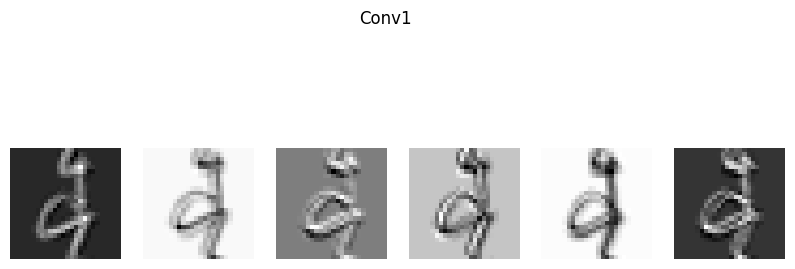

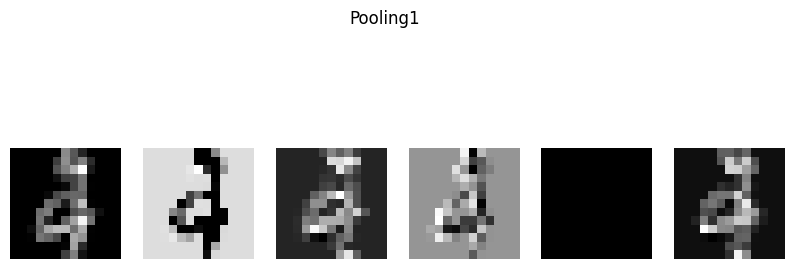

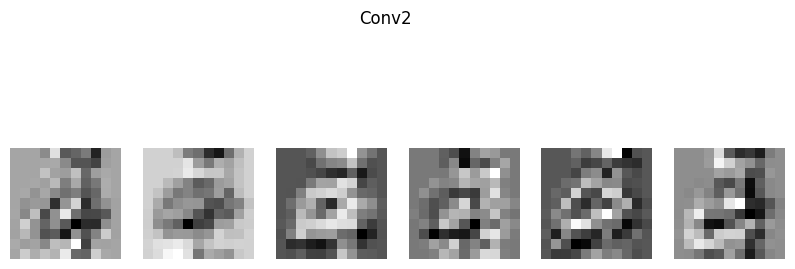

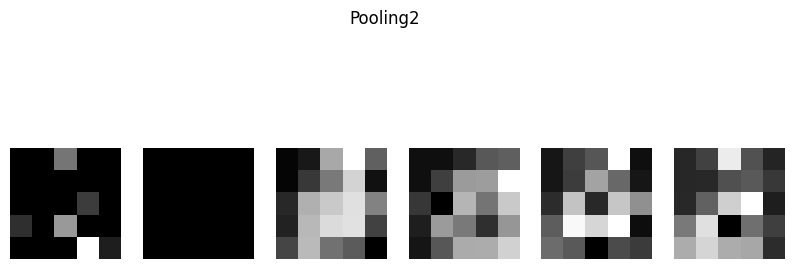

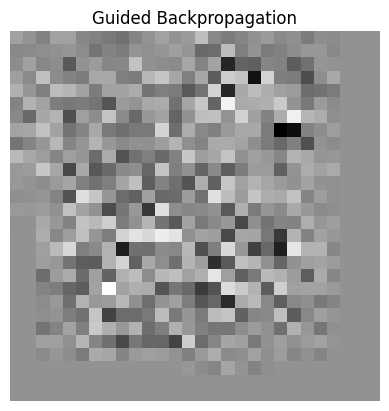

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from torch.utils.data import DataLoader, TensorDataset

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Load KMNIST (OpenML)
# =========================
kmnist = fetch_openml('Kuzushiji-MNIST', version=1)

X = kmnist.data.astype('float32') / 255.0
y = kmnist.target.astype('int64')

# reshape to (N, 1, 28, 28)
X = X.values.reshape(-1, 1, 28, 28)

# take small subset (faster)
X = X[:1000]
y = y[:1000]

# convert to torch
X_tensor = torch.tensor(X).float()
y_tensor = torch.tensor(y).long()

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

# =========================
# CNN Model
# =========================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3)
        self.conv2 = nn.Conv2d(8, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 5 * 5, 10)

    def forward(self, x):
        self.c1 = self.conv1(x)
        self.a1 = F.relu(self.c1)
        self.p1 = self.pool(self.a1)

        self.c2 = self.conv2(self.p1)
        self.a2 = F.relu(self.c2)
        self.p2 = self.pool(self.a2)

        x = self.p2.view(-1, 16 * 5 * 5)
        return self.fc(x)

model = SimpleCNN().to(device)

# =========================
# Get sample
# =========================
images, labels = next(iter(loader))
images = images.to(device)

# forward
output = model(images)

# =========================
# Feature Map Visualization
# =========================
def plot_maps(tensor, title):
    tensor = tensor.detach().cpu()
    plt.figure(figsize=(10,4))
    for i in range(min(6, tensor.shape[1])):
        plt.subplot(1,6,i+1)
        plt.imshow(tensor[0,i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_maps(model.c1, "Conv1")
plot_maps(model.p1, "Pooling1")
plot_maps(model.c2, "Conv2")
plot_maps(model.p2, "Pooling2")

# =========================
# Guided Backprop
# =========================
class GuidedReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return x.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        grad = grad_output.clone()
        grad[x < 0] = 0
        grad[grad_output < 0] = 0
        return grad

def replace_relu(module):
    for name, mod in module.named_children():
        if isinstance(mod, nn.ReLU):
            setattr(module, name, GuidedReLU.apply)
        else:
            replace_relu(mod)

replace_relu(model)

# enable gradients
images.requires_grad = True

# forward again
output = model(images)
target = output.argmax()

# backward
model.zero_grad()
output[0, target].backward()

# gradients
grads = images.grad.detach().cpu().numpy()[0][0]

# plot
plt.imshow(grads, cmap='gray')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

Feature Maps
First conv layer detects:
basic strokes and edges of Japanese characters
Second conv layer:
captures character structure and curves

Since KMNIST is handwritten Japanese script, features are:

more curved and complex than digits (MNIST)

Pooling
Reduces size:
28×28 → ~13×13 → ~5×5
Removes noise while keeping important strokes
🧠 Highlights important stroke regions
Bright pixels = strong influence

Observation:

Model focuses on:
character edges
stroke intersections

KMNIST is harder than MNIST because:
characters are visually similar
more complex patterns

Hence:

feature maps look more dense
gradients highlight fine details



In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.4947 - val_loss: 0.3457
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3183 - val_loss: 0.2946
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2722 - val_loss: 0.2697
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2521 - val_loss: 0.2567
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2411 - val_loss: 0.2477
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2338 - val_loss: 0.2419
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2288 - val_loss: 0.2387
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2255 - val_loss: 0.2367
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2243 - val_loss: 0.2356
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2232 - val_loss: 0.2349
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2225 - val_loss: 0.2344
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/ste

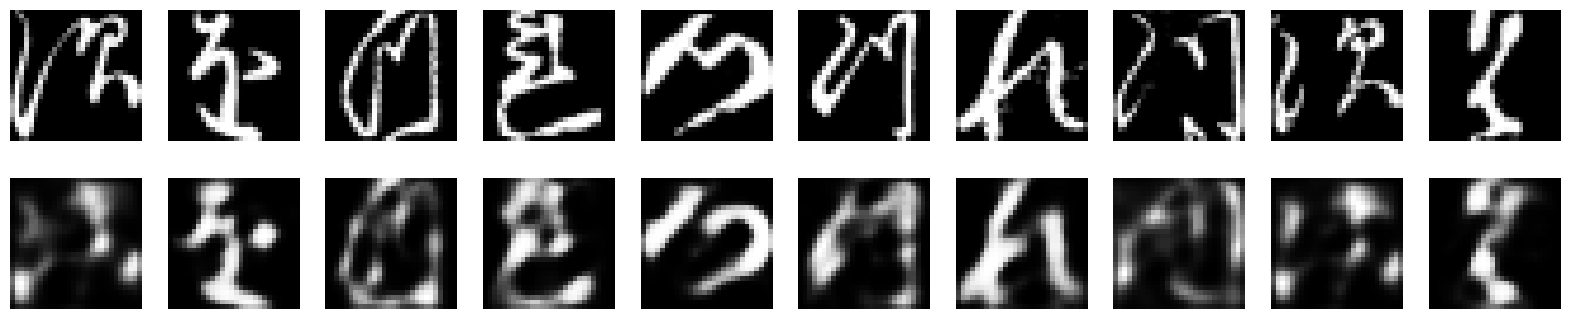

In [6]:
import numpy as np
from sklearn.datasets import fetch_openml
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# =========================
# 1. Load KMNIST (OpenML)
# =========================
kmnist = fetch_openml('Kuzushiji-MNIST', version=1)

X = kmnist.data.to_numpy().astype('float32') / 255.0 # normalize
# X shape = (70000, 784)

# split manually (same as MNIST)
x_train = X[:60000]
x_test = X[60000:]

# =========================
# 2. Model Definition
# =========================
input_dim = 784
encoding_dim = 32

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder
autoencoder = Model(input_layer, decoded)

# =========================
# 3. Compile
# =========================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 4. Train
# =========================
autoencoder.fit(
    x_train, x_train,
    epochs=30,        # reduce if slow
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# =========================
# 5. Predict
# =========================
decoded_imgs = autoencoder.predict(x_test)

# =========================
# 6. Visualization
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4705 - val_loss: 0.3033
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2704 - val_loss: 0.2422
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2205 - val_loss: 0.2122
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1967 - val_loss: 0.1967
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1841 - val_loss: 0.1884
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1771 - val_loss: 0.1845
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1738 - val_loss: 0.1818
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1717 - val_loss: 0.1803
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1703 - val_loss: 0.1795
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1696 - val_loss: 0.1786
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1688 - val_loss: 0.1782
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/

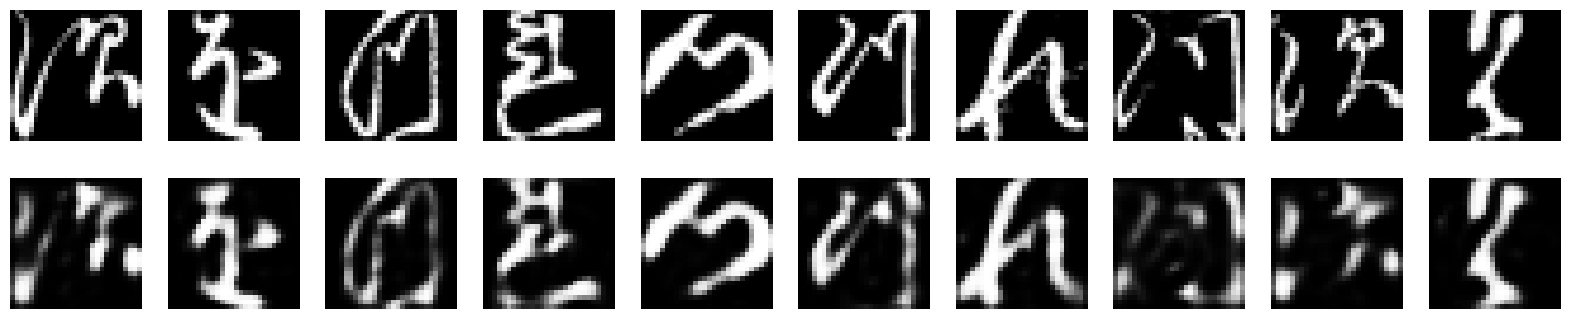

In [7]:
import numpy as np
from sklearn.datasets import fetch_openml
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# =========================
# 1. Load KMNIST (OpenML)
# =========================
kmnist = fetch_openml('Kuzushiji-MNIST', version=1)

X = kmnist.data.to_numpy().astype('float32') / 255.0 # normalize
# X shape = (70000, 784)

# split manually (same as MNIST)
x_train = X[:60000]
x_test = X[60000:]

# =========================
# 2. Model Definition
# =========================
input_dim = 784
encoding_dim = 64

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder
autoencoder = Model(input_layer, decoded)

# =========================
# 3. Compile
# =========================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 4. Train
# =========================
autoencoder.fit(
    x_train, x_train,
    epochs=30,        # reduce if slow
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# =========================
# 5. Predict
# =========================
decoded_imgs = autoencoder.predict(x_test)

# =========================
# 6. Visualization
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

Autoencoder effectively learns compressed representations of handwritten characters
Increasing encoding dimension from 32 → 64 significantly improves reconstruction quality
KMNIST requires more capacity due to complex character structures
The experiment shows that increasing latent space dimensionality improves feature representation capability of the autoencoder.